# XGBoost : prediccion de demanda de los 5 Productos
## para usar este noteboo:
1. **Cambiar solo la línea `PRODUCTO_SELECCIONADO`** en la celda de abajo
2. Correr todas las celdas de arriba a abajo (Run All)
3. Al final tenes todas las métricas y gráficos del producto elegido

**Opciones disponibles:** `"cafe"` · `"choclo"` · `"nido"` · `"sidra"` · `"vino"`


## 1. Selección de producto — **EDITÁ SOLO ESTA CELDA**

In [ ]:
# ══════════════════════════════════════════════════
#   CAMBIÁ SOLO ESTA LÍNEA — el resto es automático
# ══════════════════════════════════════════════════

PRODUCTO_SELECCIONADO = "nido"

# Opciones:
#   "cafe"   → Café Belén (281670015)
#   "choclo" → Choclo Norte (219140001)
#   "nido"   → Anita Nido Spagh (63630175)
#   "sidra"  → Sidra Preferida (181913006)
#   "vino"   → Vino Tinto (105302070)

# ══════════════════════════════════════════════════
print(f"✅ Producto seleccionado: {PRODUCTO_SELECCIONADO.upper()}")


✅ Producto seleccionado: CAFE


## 2. Configuración por producto — automática

In [34]:
# Configuración óptima descubierta para cada producto
# (no modificar — resultado del análisis previo)

CONFIGS = {
    "cafe": {
        "archivo":       "G:\My Drive\ElCapstone\Capstone\Documentos Generados\CafeBelenTotal.xlsx",
        "nombre":        "Café Belén",
        "producto_id":   281670015,
        "caso":          3,          # netear devoluciones
        "cohorte_max":   2022,       # solo sucursales abiertas hasta 2022
        "capeo_iqr":     True,       # tiene outliers reales ago-2021 y dic-2022
        "features_extra":["navidad", "temporada_alta"],
        "justificacion": "Caso 3 + cohorte ≤2022 + capeo IQR + navidad + temporada oct-dic"
    },
    "choclo": {
        "archivo":       "G:\My Drive\ElCapstone\Capstone\Documentos Generados\ChocloNorteTotal.xlsx",
        "nombre":        "Choclo Norte",
        "producto_id":   219140001,
        "caso":          3,
        "cohorte_max":   None,       # sin filtro — creció 28% anual, filtrar destruye el modelo
        "capeo_iqr":     False,      # sin outliers reales
        "features_extra":["invierno"],
        "justificacion": "Caso 3 + sin cohorte + sin capeo + invierno jun-jul"
    },
    "nido": {
        "archivo":       "G:\My Drive\ElCapstone\Capstone\Documentos Generados\FideoTotal.xlsx",
        "nombre":        "Nido Spagh",
        "producto_id":   63630175,
        "caso":          1,
        "cohorte_max":   2022,
        "capeo_iqr":     False,
        "features_extra":["navidad"],
        "justificacion": "Caso 1 + cohorte ≤2022 + sin capeo + navidad"
    },
    "sidra": {
        "archivo":       "G:\My Drive\ElCapstone\Capstone\Documentos Generados\SidraTotal.xlsx",
        "nombre":        "Sidra Preferida",
        "producto_id":   181913006,
        "caso":          1,
        "cohorte_max":   None,       # sin filtro — pico estacional extremo
        "capeo_iqr":     False,      # NO capear — pico oct-nov ES la señal real
        "features_extra":[],         # ninguna feature extra mejoró
        "justificacion": "Caso 1 + sin cohorte + sin capeo (picos son estacionalidad real)"
    },
    "vino": {
        "archivo":       "G:\My Drive\ElCapstone\Capstone\Documentos Generados\VinoTotal.xlsx",
        "nombre":        "Vino Tinto",
        "producto_id":   105302070,
        "caso":          1,
        "cohorte_max":   2022,
        "capeo_iqr":     False,      # pico jun-jul es invierno real — no capear
        "features_extra":[],
        "justificacion": "Caso 1 + cohorte ≤2022 + sin capeo"
    },
}

cfg = CONFIGS[PRODUCTO_SELECCIONADO]
print(f"\n{'='*55}")
print(f"  PRODUCTO : {cfg['nombre']}")
print(f"  ID       : {cfg['producto_id']}")
print(f"  Caso     : {cfg['caso']}")
print(f"  Cohorte  : {'≤' + str(cfg['cohorte_max']) if cfg['cohorte_max'] else 'todas las sucursales'}")
print(f"  Capeo    : {'Sí (IQR)' if cfg['capeo_iqr'] else 'No'}")
print(f"  Features : {cfg['features_extra'] if cfg['features_extra'] else 'ninguna extra'}")
print(f"  Justif.  : {cfg['justificacion']}")
print(f"{'='*55}")



  PRODUCTO : Café Belén
  ID       : 281670015
  Caso     : 3
  Cohorte  : ≤2022
  Capeo    : Sí (IQR)
  Features : ['navidad', 'temporada_alta']
  Justif.  : Caso 3 + cohorte ≤2022 + capeo IQR + navidad + temporada oct-dic


## 3. Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    import xgboost as xgb
    USE_XGB = True
    print("✅ XGBoost listo")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False
    print("⚠️  Usando GradientBoostingRegressor")

# Semana Santa en Paraguay por año (mes donde cae)
SEMANA_SANTA = {2021: 4, 2022: 4, 2023: 4, 2024: 3, 2025: 4, 2026: 4}
print("✅ Imports OK")


✅ XGBoost listo
✅ Imports OK


## 4. Carga y preprocessing — automático según producto

Registros: 5127 | Negativos: 157 | Ceros: 53
Aplicando Caso 3: neteando devoluciones contra mes anterior...
Cohorte ≤2022: 166 sucursales

Capeo IQR — límite: 8814
  2021-08: 12378 → 8814
  2022-12: 13089 → 8814
  2 meses capeados

Serie final: 62 meses | Promedio: 3335 u/mes


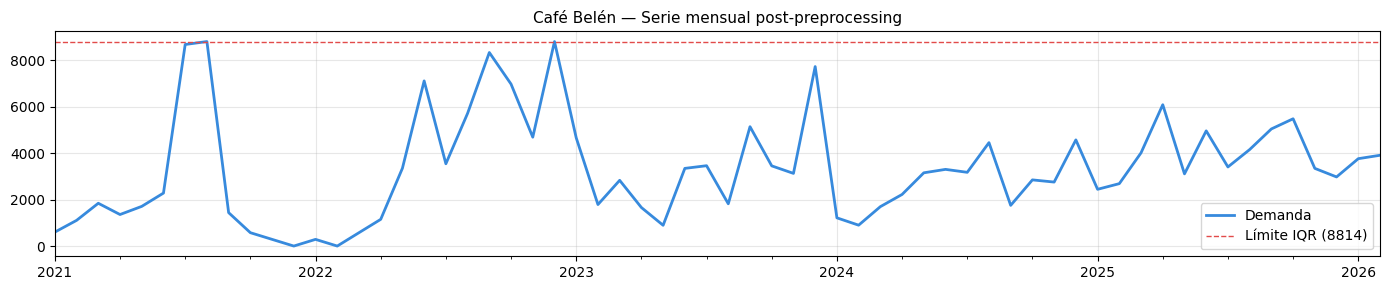

✅ Preprocessing listo


In [36]:
# ── Cargar datos ─────────────────────────────────────
df = pd.read_excel(cfg["archivo"], sheet_name="Datos Producto")
df["Mes"] = pd.to_datetime(df["Mes"])
df = df[df["Producto"] == cfg["producto_id"]].copy()
df = df.sort_values(["NomClienteAlter", "Mes"]).reset_index(drop=True)

print(f"Registros: {len(df)} | Negativos: {(df['Demanda']<0).sum()} | Ceros: {(df['Demanda']==0).sum()}")

# ── Caso de limpieza ──────────────────────────────────
if cfg["caso"] == 3:
    print("Aplicando Caso 3: neteando devoluciones contra mes anterior...")
    for idx in df[df["Demanda"] < 0].index:
        cli   = df.loc[idx, "NomClienteAlter"]
        mes_d = df.loc[idx, "Mes"]
        dev   = df.loc[idx, "Demanda"]
        prev  = df[(df["NomClienteAlter"]==cli) & (df["Mes"]<mes_d)]
        if not prev.empty:
            pi = prev.index[-1]
            df.loc[pi, "Demanda"] = max(0, df.loc[pi, "Demanda"] + dev)
        df.loc[idx, "Demanda"] = 0
else:
    print("Aplicando Caso 1: negativos → 0...")
    df["Demanda"] = df["Demanda"].clip(lower=0)

# ── Filtro de cohortes ────────────────────────────────
if cfg["cohorte_max"]:
    primera = df[df["Demanda"]>0].groupby("NomClienteAlter")["Mes"].min().rename("apertura")
    df = df.merge(primera, on="NomClienteAlter")
    df = df[df["apertura"].dt.year <= cfg["cohorte_max"]].copy()
    print(f"Cohorte ≤{cfg['cohorte_max']}: {df['NomClienteAlter'].nunique()} sucursales")
else:
    print(f"Sin filtro de cohorte: {df['NomClienteAlter'].nunique()} sucursales")

# ── Serie mensual ─────────────────────────────────────
ts = df.groupby("Mes")["Demanda"].sum().astype(float)
ts = ts.reindex(pd.date_range(ts.index.min(), ts.index.max(), freq="MS")).fillna(0.0)

# ── Capeo IQR ─────────────────────────────────────────
Q1 = ts.quantile(0.25); Q3 = ts.quantile(0.75); IQR = Q3 - Q1
lim_iqr = float(Q3 + 1.5 * IQR)
outliers = ts[ts > lim_iqr]

if cfg["capeo_iqr"] and len(outliers) > 0:
    print(f"\nCapeo IQR — límite: {lim_iqr:.0f}")
    for f, v in outliers.items():
        print(f"  {f.strftime('%Y-%m')}: {v:.0f} → {lim_iqr:.0f}")
    ts = ts.clip(upper=lim_iqr)
    print(f"  {len(outliers)} meses capeados")
elif not cfg["capeo_iqr"]:
    print(f"\nCapeo IQR: no aplicado (outliers detectados: {len(outliers)})")
    if len(outliers) > 0:
        meses_out = [f.strftime('%Y-%m (%s)' % f.strftime('%b')) for f in outliers.index]
        print(f"  Estos picos son estacionalidad real — no se capean: {list(outliers.index.strftime('%Y-%m'))}")
else:
    print(f"\nCapeo IQR: no necesario (0 outliers detectados)")

print(f"\nSerie final: {len(ts)} meses | Promedio: {ts.mean():.0f} u/mes")

# ── Gráfico de la serie ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ts.plot(ax=ax, color="#378ADD", linewidth=2)
if cfg["capeo_iqr"]:
    ax.axhline(lim_iqr, color="#E24B4A", linestyle="--", linewidth=1,
               label=f"Límite IQR ({lim_iqr:.0f})")
    ax.legend()
ax.set_title(f"{cfg['nombre']} — Serie mensual post-preprocessing", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("✅ Preprocessing listo")


## 5. Modelo, features y métricas

In [37]:
def construir_modelo():
    if USE_XGB:
        return xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0)
    return GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42)

def construir_features(ts, features_extra):
    """
    Features base + features específicas del producto.
    Lags, rolling stats, YoY — capturan tendencia y estacionalidad.
    Features extra: flags de calendario paraguayo según el producto.
    """
    df = pd.DataFrame({"y": ts.astype(float)}).reset_index()
    df.columns = ["fecha", "y"]
    df["mes_num"]    = df["fecha"].dt.month
    df["trimestre"]  = df["fecha"].dt.quarter
    df["año"]        = df["fecha"].dt.year
    df["t"]          = range(len(df))
    df["t2"]         = df["t"] ** 2
    for lag in [1, 2, 3, 4, 6, 12, 13, 24]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    for v in [3, 6, 12]:
        df[f"roll_mean_{v}"] = df["y"].shift(1).rolling(v).mean()
        df[f"roll_std_{v}"]  = df["y"].shift(1).rolling(v).std()
        df[f"roll_max_{v}"]  = df["y"].shift(1).rolling(v).max()
    df["yoy_change"]  = df["y"].shift(1) - df["y"].shift(13)
    df["yoy_ratio"]   = df["y"].shift(1) / (df["y"].shift(13) + 1)
    df["ratio_trend"] = (df["y"].shift(1).rolling(3).mean() /
                        (df["y"].shift(1).rolling(12).mean() + 1))
    df["diff_1"] = df["y"].diff(1)

    # Features de calendario según el producto
    if "navidad" in features_extra:
        df["navidad"] = df["fecha"].dt.month.isin([11, 12]).astype(int)
    if "temporada_alta" in features_extra:
        df["temporada_alta"] = df["fecha"].dt.month.isin([10, 11, 12]).astype(int)
    if "semana_santa" in features_extra:
        df["semana_santa"] = df.apply(
            lambda r: 1 if SEMANA_SANTA.get(r["fecha"].year)==r["fecha"].month else 0, axis=1)
    if "invierno" in features_extra:
        df["invierno"] = df["fecha"].dt.month.isin([6, 7]).astype(int)
    if "temporada_sidra" in features_extra:
        df["temporada_sidra"] = df["fecha"].dt.month.isin([10, 11, 12]).astype(int)

    return df

def walk_forward_cv(ts, features_extra, min_train=24, ventana=36):
    """
    Walk-Forward CV: entrena con el pasado, predice el siguiente mes.
    Nunca ve el futuro — simula el modelo en producción real.
    Más riguroso que un split fijo (train/test) porque evalúa múltiples períodos.
    """
    df = construir_features(ts, features_extra).dropna().reset_index(drop=True)
    fc = [c for c in df.columns if c not in ["fecha", "y"]]
    X  = df[fc].values
    y  = df["y"].values
    fechas = df["fecha"].values
    actuals, preds, dates = [], [], []
    for i in range(min_train, len(df)):
        start = max(0, i - ventana)
        model = construir_modelo()
        model.fit(X[start:i], y[start:i])
        pred = max(0.0, float(model.predict(X[i:i+1])[0]))
        preds.append(pred)
        actuals.append(float(y[i]))
        dates.append(pd.Timestamp(fechas[i]))
    return np.array(actuals), np.array(preds), dates

def calcular_metricas(actuals, preds, label=""):
    """
    MAE     → error en unidades. Ej: 637 u/mes de error promedio.
    RMSE    → penaliza errores grandes.
    MAPE    → error %. Puede explotar con valores cercanos a 0.
    SMAPE   → error % robusto. Métrica principal para comparar entre casos.
    WAPE    → error ponderado por volumen. Comparable con Tamara/Álvaro.
    MAE%    → MAE como % de la demanda media. Comparable entre productos.
    Bias    → sesgo: + sobreestima, - subestima. Ideal = 0.
    R²      → varianza explicada. 1=perfecto, <0=peor que el promedio.
    """
    mae   = mean_absolute_error(actuals, preds)
    rmse  = np.sqrt(mean_squared_error(actuals, preds))
    mask  = actuals > 0
    mape  = np.mean(np.abs((actuals[mask]-preds[mask])/actuals[mask]))*100
    smape = np.mean(2*np.abs(actuals-preds)/(np.abs(actuals)+np.abs(preds)+1e-9))*100
    wape  = np.sum(np.abs(actuals-preds)) / np.sum(actuals) * 100
    mae_pct = mae / np.mean(actuals) * 100
    bias  = np.mean(preds - actuals)
    ss_r  = np.sum((actuals-preds)**2)
    ss_t  = np.sum((actuals-actuals.mean())**2)
    r2    = 1 - ss_r/ss_t if ss_t > 0 else float("nan")
    return dict(label=label, MAE=mae, RMSE=rmse, MAPE=mape, SMAPE=smape,
                WAPE=wape, MAE_pct=mae_pct, Bias=bias, R2=r2, n=len(actuals))

def imprimir_metricas(m):
    print(f"  MAE     : {m['MAE']:>8.1f}  unidades por período")
    print(f"  RMSE    : {m['RMSE']:>8.1f}  penaliza errores grandes")
    print(f"  MAPE    : {m['MAPE']:>7.2f}%")
    print(f"  SMAPE   : {m['SMAPE']:>7.2f}%  ← métrica principal entre casos")
    print(f"  WAPE    : {m['WAPE']:>7.2f}%  ← comparable con Tamara/Álvaro")
    print(f"  MAE%    : {m['MAE_pct']:>7.2f}%  ← MAE como % de demanda media")
    print(f"  Bias    : {m['Bias']:>+8.1f}  (+ sobreestima / - subestima)")
    print(f"  R²      : {m['R2']:>8.3f}")

print("✅ Funciones listas")


✅ Funciones listas


## 6. Correr el modelo

In [38]:
print(f"Corriendo Walk-Forward CV para {cfg['nombre']}...")
print(f"Features extra: {cfg['features_extra'] if cfg['features_extra'] else 'ninguna'}")
print()

actuals, preds, dates = walk_forward_cv(ts, cfg["features_extra"])

print(f"✅ Predicciones generadas: {len(preds)} meses evaluados")
print(f"   Período: {dates[0].strftime('%Y-%m')} → {dates[-1].strftime('%Y-%m')}")


Corriendo Walk-Forward CV para Café Belén...
Features extra: ['navidad', 'temporada_alta']

✅ Predicciones generadas: 14 meses evaluados
   Período: 2025-01 → 2026-02


## 7. Métricas — período completo (walk-forward)

In [39]:
m_total = calcular_metricas(actuals, preds, f"{cfg['nombre']} — Walk-Forward completo")

print("=" * 55)
print(f"  {cfg['nombre'].upper()} — WALK-FORWARD CV COMPLETO")
print(f"  {m_total['n']} meses evaluados")
print("=" * 55)
imprimir_metricas(m_total)


  CAFÉ BELÉN — WALK-FORWARD CV COMPLETO
  14 meses evaluados
  MAE     :    866.4  unidades por período
  RMSE    :   1105.1  penaliza errores grandes
  MAPE    :   20.32%
  SMAPE   :   21.82%  ← métrica principal entre casos
  WAPE    :   21.88%  ← comparable con Tamara/Álvaro
  MAE%    :   21.88%  ← MAE como % de demanda media
  Bias    :   -420.1  (+ sobreestima / - subestima)
  R²      :   -0.109


## 8. Métricas — período 2025-2026 (comparable con tam y alvaro)

> tam y alvaro usan **train: 2021-2024 | test: 2025 + ene-feb 2026**.
> Esta celda filtra las predicciones al mismo período para comparación directa.


In [40]:
# Filtrar solo 2025 y 2026
idx_2025 = [i for i, d in enumerate(dates) if d.year >= 2025]

if idx_2025:
    a_2025 = actuals[idx_2025]
    p_2025 = preds[idx_2025]
    d_2025 = [dates[i] for i in idx_2025]

    m_2025 = calcular_metricas(a_2025, p_2025, f"{cfg['nombre']} — 2025-2026")

    print("=" * 55)
    print(f"  {cfg['nombre'].upper()} — PERÍODO 2025-2026")
    print(f"  {m_2025['n']} meses | {d_2025[0].strftime('%Y-%m')} → {d_2025[-1].strftime('%Y-%m')}")
    print(f"  (mismo período de test que Tamara y Álvaro)")
    print("=" * 55)
    imprimir_metricas(m_2025)
else:
    print("⚠️  No hay predicciones en el período 2025-2026")
    m_2025 = m_total


  CAFÉ BELÉN — PERÍODO 2025-2026
  14 meses | 2025-01 → 2026-02
  (mismo período de test que Tamara y Álvaro)
  MAE     :    866.4  unidades por período
  RMSE    :   1105.1  penaliza errores grandes
  MAPE    :   20.32%
  SMAPE   :   21.82%  ← métrica principal entre casos
  WAPE    :   21.88%  ← comparable con Tamara/Álvaro
  MAE%    :   21.88%  ← MAE como % de demanda media
  Bias    :   -420.1  (+ sobreestima / - subestima)
  R²      :   -0.109


## 9. Gráfico — real vs predicho

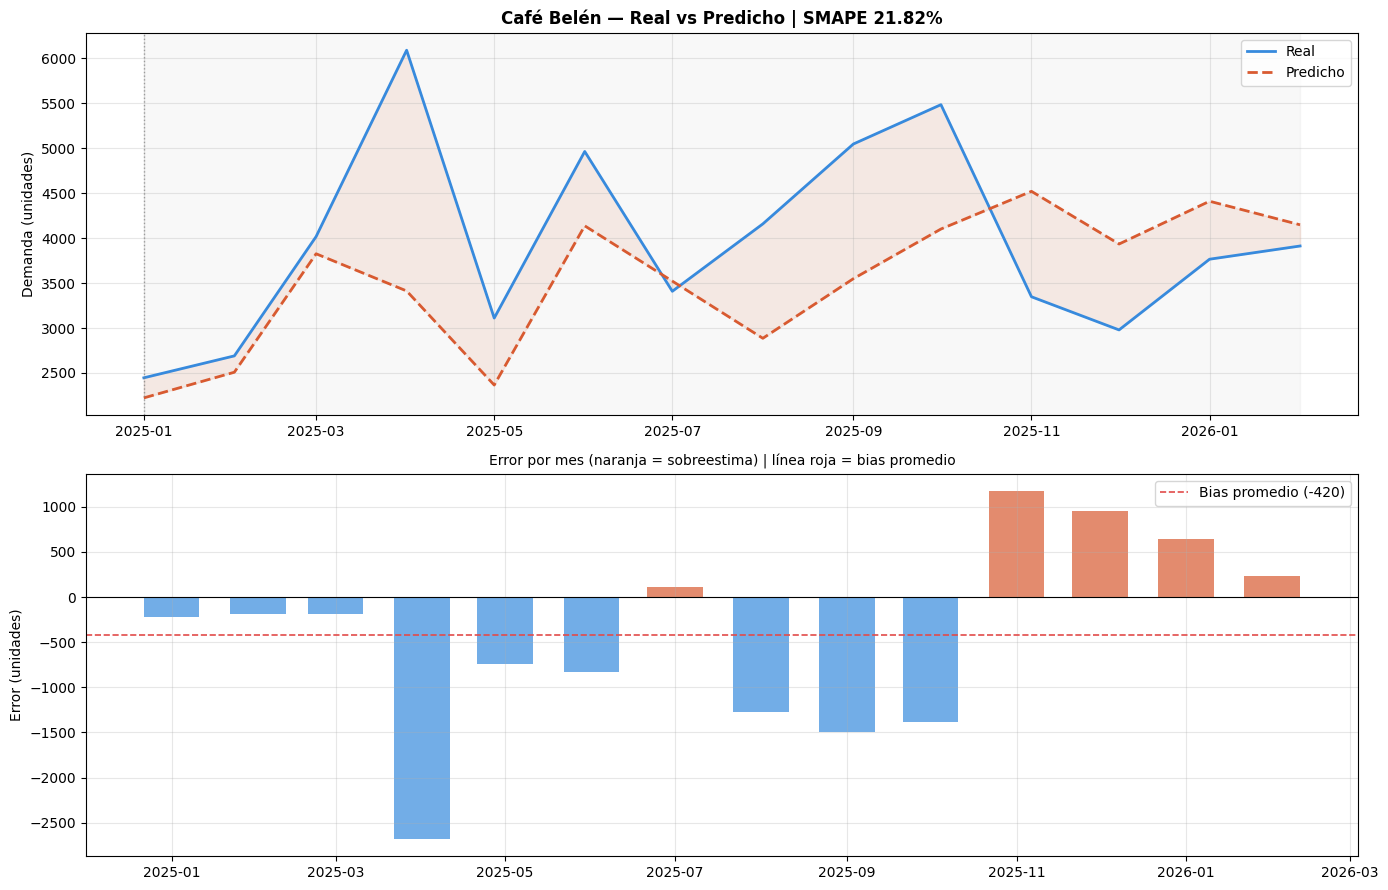

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

color_prod = {"cafe":"#378ADD","choclo":"#1D9E75","nido":"#888780",
              "sidra":"#EF9F27","vino":"#D85A30"}
color = color_prod.get(PRODUCTO_SELECCIONADO, "#378ADD")

# Real vs predicho
axes[0].plot(dates, actuals, label="Real", color=color, linewidth=2)
axes[0].plot(dates, preds, label="Predicho", color="#D85A30",
             linewidth=2, linestyle="--")
axes[0].fill_between(dates, actuals, preds, alpha=0.1, color="#D85A30")
axes[0].set_title(f"{cfg['nombre']} — Real vs Predicho | SMAPE {m_total['SMAPE']:.2f}%",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Demanda (unidades)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Zona 2025-2026 destacada
if idx_2025:
    axes[0].axvline(dates[idx_2025[0]], color="gray", linewidth=1,
                    linestyle=":", alpha=0.7, label="Inicio 2025")
    axes[0].axvspan(dates[idx_2025[0]], dates[-1], alpha=0.05, color="gray")

# Error por mes
errores = preds - actuals
colores_err = ["#D85A30" if e > 0 else color for e in errores]
axes[1].bar(dates, errores, color=colores_err, alpha=0.7, width=20)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(m_total["Bias"], color="#E24B4A", linewidth=1.2,
                linestyle="--", label=f"Bias promedio ({m_total['Bias']:+.0f})")
axes[1].set_title("Error por mes (naranja = sobreestima) | línea roja = bias promedio",
                  fontsize=10)
axes[1].set_ylabel("Error (unidades)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Resumen final — copiá esto para el reporte

In [42]:
print("=" * 60)
print(f"  RESUMEN FINAL — {cfg['nombre'].upper()}")
print("=" * 60)
print(f"  Archivo      : {cfg['archivo']}")
print(f"  Preprocessing: {cfg['justificacion']}")
print()
print("  WALK-FORWARD COMPLETO:")
print(f"    SMAPE  : {m_total['SMAPE']:.2f}%")
print(f"    WAPE   : {m_total['WAPE']:.2f}%")
print(f"    MAE    : {m_total['MAE']:.1f} unidades/mes")
print(f"    MAE%   : {m_total['MAE_pct']:.2f}%")
print(f"    Bias   : {m_total['Bias']:+.1f} unidades/mes")
print(f"    R²     : {m_total['R2']:.3f}")
print(f"    N      : {m_total['n']} meses")
print()
print("  PERÍODO 2025-2026 (comparable con SARIMA/STL):")
print(f"    SMAPE  : {m_2025['SMAPE']:.2f}%")
print(f"    WAPE   : {m_2025['WAPE']:.2f}%")
print(f"    MAE    : {m_2025['MAE']:.1f} unidades/mes")
print(f"    MAE%   : {m_2025['MAE_pct']:.2f}%")
print(f"    Bias   : {m_2025['Bias']:+.1f} unidades/mes")
print(f"    N      : {m_2025['n']} meses")
print()
if m_total["Bias"] < -100:
    print(f"  ⚠️  Bias negativo ({m_total['Bias']:+.0f}) → el modelo SUBESTIMA")
    factor = abs(m_total["Bias"])
    print(f"     Factor de seguridad sugerido: +{factor:.0f} u/mes sobre la predicción")
elif m_total["Bias"] > 100:
    print(f"  ⚠️  Bias positivo ({m_total['Bias']:+.0f}) → el modelo SOBREESTIMA")
else:
    print(f"  ✅ Bias bajo ({m_total['Bias']:+.0f}) → sin sesgo sistemático importante")
print("=" * 60)


  RESUMEN FINAL — CAFÉ BELÉN
  Archivo      : G:\My Drive\ElCapstone\Capstone\Documentos Generados\CafeBelenTotal.xlsx
  Preprocessing: Caso 3 + cohorte ≤2022 + capeo IQR + navidad + temporada oct-dic

  WALK-FORWARD COMPLETO:
    SMAPE  : 21.82%
    WAPE   : 21.88%
    MAE    : 866.4 unidades/mes
    MAE%   : 21.88%
    Bias   : -420.1 unidades/mes
    R²     : -0.109
    N      : 14 meses

  PERÍODO 2025-2026 (comparable con SARIMA/STL):
    SMAPE  : 21.82%
    WAPE   : 21.88%
    MAE    : 866.4 unidades/mes
    MAE%   : 21.88%
    Bias   : -420.1 unidades/mes
    N      : 14 meses

  ⚠️  Bias negativo (-420) → el modelo SUBESTIMA
     Factor de seguridad sugerido: +420 u/mes sobre la predicción
